In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler


In [ ]:
# Fetch Google (GOOGL) stock data from Yahoo Finance (2012-2016)
data = yf.download('GOOGL', start='2012-01-01', end='2016-12-31')

# Display the first few rows of data
data.head()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2012-01-03,16.572668,16.640911,16.247896,16.262092,146912940
2012-01-04,16.644150,16.693214,16.453370,16.563204,114445440
2012-01-05,16.413269,16.536803,16.344031,16.490977,131184684
2012-01-06,16.189367,16.437929,16.183638,16.416758,107608284
2012-01-09,15.502957,16.114149,15.472323,16.101696,232671096


In [ ]:
# Use only the 'Open' price for prediction
open_prices = data[['Open']].values

# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
open_prices_scaled = scaler.fit_transform(open_prices)

# Prepare sequences (previous 60 days' data to predict the next day)
X_train = []
y_train = []

for i in range(60, len(open_prices_scaled)):
    X_train.append(open_prices_scaled[i-60:i, 0])  # Previous 60 days
    y_train.append(open_prices_scaled[i, 0])       # Predict next day

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for RNN input (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


In [ ]:
# Build the RNN model
model = tf.keras.Sequential([
    layers.SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    layers.SimpleRNN(50),
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0593
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0015
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9.2841e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.3403e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.0153e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.5273e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.4374e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.1309e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 4.6640e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 4.3614e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.1874e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.5398e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.5987e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.6041e-04
Epoch 15/20
38/38 ━━━━━

In [ ]:
# Fetch test data (last 2 years of stock data)
test_data = yf.download('GOOGL', start='2017-01-01', end='2017-12-31')
real_stock_price = test_data[['Open']].values

# Combine train and test data
total_data = pd.concat((data['Open'], test_data['Open']), axis=0)

# Prepare input for prediction
inputs = total_data[len(total_data) - len(test_data) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Predict stock prices
predicted_stock_price = model.predict(X_test)

# Reverse scaling to get actual stock price predictions
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)


[*********************100%***********************]  1 of 1 completed


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


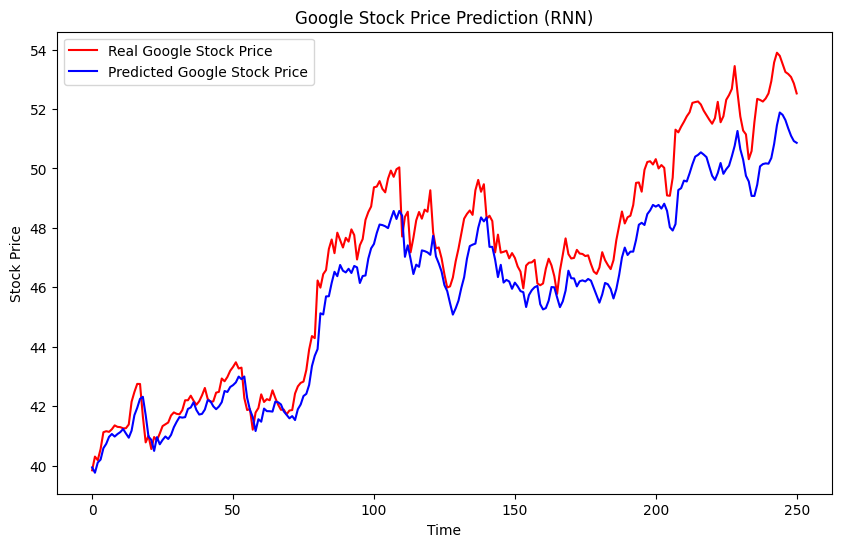

In [ ]:
# Plot the real and predicted stock prices
plt.figure(figsize=(10,6))
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction (RNN)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


1. What is the goal of this code?
Answer:
The goal is to predict Google's stock opening price using a Recurrent Neural Network (RNN) trained on past stock data.

2. Which library do you use to fetch stock data?
Answer:
I use the yfinance library to download stock data from Yahoo Finance.

3. Which stock and what period are you training on?
Answer:
I'm training on Google (GOOGL) stock data from 2012 to 2016.

4. What feature are you using for prediction?
Answer:
I only use the 'Open' price of the stock.

5. Why do you scale the data between 0 and 1?
Answer:
To normalize the data, which helps the RNN model train faster and better.

6. Which scaler are you using?
Answer:
I use MinMaxScaler from sklearn.preprocessing.

7. How do you prepare the training data?
Answer:
I take the previous 60 days' open prices as input to predict the next day's open price.

8. What is the shape of the training input to the RNN?
Answer:
The shape is (samples, 60 timesteps, 1 feature).

9. What is the architecture of your RNN model?
Answer:

SimpleRNN layer with 50 units (returning sequences)

Another SimpleRNN layer with 50 units

Dense layer with 1 neuron for output

10. What activation function is used in SimpleRNN?
Answer:
By default, SimpleRNN uses tanh activation.

11. What loss function and optimizer are you using?
Answer:
Loss function: Mean Squared Error (MSE)
Optimizer: Adam

12. How many epochs and batch size did you use for training?
Answer:
I trained for 20 epochs with a batch size of 32.

13. How is the test data prepared?
Answer:
I use Google's stock data from 2017 as the test set and prepare it the same way using previous 60 days' prices.

14. Why do you combine training and testing 'Open' prices?
Answer:
To make sure we have the last 60 days' data before the test period starts.

15. How do you predict the stock price for the test set?
Answer:
I feed the scaled sequences of past 60 days to the trained RNN and get the predicted next day's price.

16. What do you do after predicting?
Answer:
I apply the inverse transform of the scaler to get back the actual stock price values.

17. How do you visualize the performance?
Answer:
I plot the real vs predicted stock prices using matplotlib.

18. Why do you use RNN for stock price prediction?
Answer:
Because RNNs are good at handling sequential time-series data and learning temporal dependencies.

19. What is the major limitation of this model?
Answer:
Simple RNNs can suffer from vanishing gradient problems for very long sequences and might not capture very long-term dependencies well.

20. How could you improve the model?
Answer:
I could use LSTM or GRU layers instead of SimpleRNN for better performance on longer sequences.

